---
---

<h1><center><ins>Exercise Sheet 9</ins></center></h1>
<h2><center>Numerical Methods <br>

---
---

# Exercise 1 - Fit a straight line 

The attached data file (```mmr_lg.dat```) contains observations of two quantities (mass and metallicity) measured for a sample of nearby galaxies. This file contains four columns: log10(mass), average metallicity, error on log10(mass) and error on average metallicity. 

*For this exercise, you can neglect the error on the mass, and consider only the one on the metallicity.*

**(A)** Fit a straight line to this dataset. To do this, first write down your model, and define the model parameters you will consider. By using the equations we saw in the lecture, compute:

* the best-fit values for your model parameters
* the uncertainties on the parameters, the covariance and the correlation coefficient $r_{\rm ab}$ on the parameters errors
* the goodness of fit. 

Best-fit parameters:
  a (slope)     = 0.272048 ± 0.043206
  b (intercept) = -3.450291 ± 0.271699

Covariance and correlation:
  cov(a,b) = -1.131905e-02
  r_ab     = -0.964232

Goodness of fit:
  chi^2       = 19.928
  chi^2_red   = 1.172
  dof         = 17


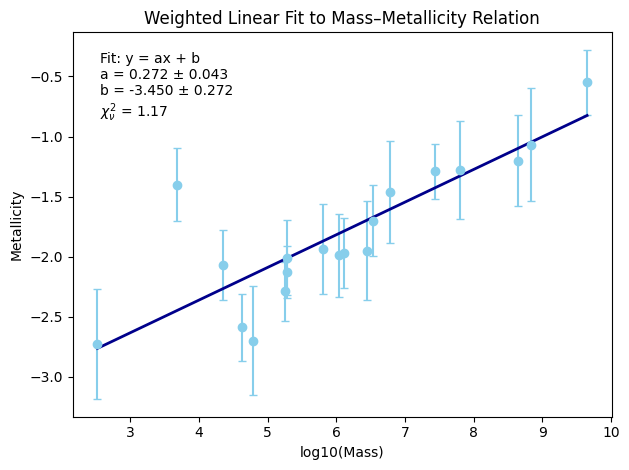

In [18]:
import numpy as np
import matplotlib.pyplot as plt


x, y, sx, sy = np.loadtxt("mmr_lg.dat", unpack=True)


# Define weights (only y-errors)
w = 1.0 / sy**2

# Weighted linear least-squares fit: y = a x + b
S   = np.sum(w)
Sx  = np.sum(w * x)
Sy  = np.sum(w * y)
Sxx = np.sum(w * x * x)
Sxy = np.sum(w * x * y)

Delta = S * Sxx - Sx**2

a = (S * Sxy - Sx * Sy) / Delta   # slope 
b = (Sxx * Sy - Sx * Sxy) / Delta # intercept
# in the lecture notes b is the slope and a the intercept


# Parameter uncertainties and covariance
sigma_a2 = S / Delta
sigma_b2 = Sxx / Delta
cov_ab   = -Sx / Delta

sigma_a = np.sqrt(sigma_a2)
sigma_b = np.sqrt(sigma_b2)

# Correlation coefficient
r_ab = -Sx / np.sqrt(S * Sxx)


# Goodness of fit (chi-square)
y_model = a * x + b
chi2 = np.sum(((y - y_model) / sy)**2)

dof = len(x) - 2
chi2_red = chi2 / dof


print("Best-fit parameters:")
print(f"  a (slope)     = {a:.6f} ± {sigma_a:.6f}")
print(f"  b (intercept) = {b:.6f} ± {sigma_b:.6f}")

print("\nCovariance and correlation:")
print(f"  cov(a,b) = {cov_ab:.6e}")
print(f"  r_ab     = {r_ab:.6f}")

print("\nGoodness of fit:")
print(f"  chi^2       = {chi2:.3f}")
print(f"  chi^2_red   = {chi2_red:.3f}")
print(f"  dof         = {dof}") # degrees of freedom



x_plot = np.linspace(np.min(x), np.max(x), 200)
y_plot = a * x_plot + b

plt.figure()
plt.errorbar(x, y, yerr=sy, fmt='o', capsize=3, color="skyblue")
plt.plot(x_plot, y_plot, linewidth=2, color="darkblue")
plt.xlabel("log10(Mass)")
plt.ylabel("Metallicity")
plt.title("Weighted Linear Fit to Mass–Metallicity Relation")

label = (
    f"Fit: y = ax + b\n"
    f"a = {a:.3f} ± {sigma_a:.3f}\n"
    f"b = {b:.3f} ± {sigma_b:.3f}\n"
    f"$\\chi^2_\\nu$ = {chi2_red:.2f}"
)
plt.text(0.05, 0.95, label, transform=plt.gca().transAxes,
         verticalalignment='top')

plt.tight_layout()
plt.show()

**(B)** Discuss the results you obtained in point (A).

Data roughly follows a straight line with a few outliers. $\chi^2$ shows rather good correlation.

**(C)** Compute the Pearson's correlation coefficient $r$ for this data set. How does it relate to the goodness of fit you recovered above? Is it useful to consider this quantity in this case? Why?

Goodness of fit ($\chi^2$) tells us how good the data fits the curve and $r$ measures how the uncertainties in the fitted parameters are related. Here $r$ is useful because we want to know the uncertainties of the parameters and how they are related.

# Exercise 2 - Familiarize with python built-in functions

**(A)** Take a look at the documentation of the following 3 python built-in functions:

* ```numpy.polynomial.polynomial.Polynomial.fit``` (https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.fit.html)
* ```scipy.stats.linregress``` (https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html)
* ```scipy.optimize.curve_fit``` (https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)

Pay attention especially to the quantities and parameters that you need to provide to run these functions, and to those that are returned as result. For each function, provide an answer to the following questions:

1. What possible applications can this function be used for? (e.g.: fit of a straight line to data with errors on the dependent variable)
2. Are the returned quantities providing a full description of the fit? If not, what is missing?

\begin{aligned}
\texttt{Polynomial.fit:} &\ \text{Least squares polynomial data fit, no uncertainties, only residuals} \\
\texttt{linregress:} &\ \text{Linear fit with errors, no covariance} \\
\texttt{curve\_fit:} &\ \text{Nonlinear model fit, covariance included, no residuals ($\chi^2$)}
\end{aligned}


**(B)** Use all the above functions to fit a straight line to the set of data from Exercise 1. What are the results you get for each of these methods? What differences do you find? Compare them also to the ones you obtained in Exercise 1: are there any differences?

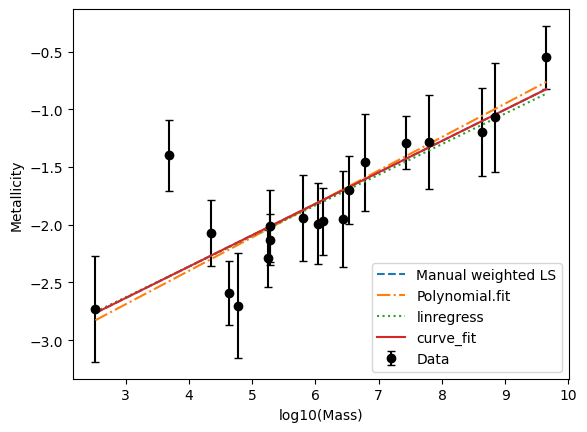

Method                       Slope  Intercept  Slope_err Intercept_err     r_ab   Chi2_red
------------------------------------------------------------------------------------------
Manual weighted LS          0.2720    -3.4503     0.0432        0.2717  -0.9642       1.17
Polynomial.fit              0.2896    -3.5569          -             -        -      12.97
linregress (unweighted)     0.2651    -3.4226     0.0438        0.2778   0.8267          -
curve_fit                   0.2720    -3.4503     0.0432        0.2717  -0.9642          -


In [62]:
from numpy.polynomial.polynomial import Polynomial
from scipy.stats import linregress
from scipy.optimize import curve_fit


# Polynomial.fit
p, stats = Polynomial.fit(x, y, 1, w=1/sy**2, full=True)
intercept_poly, slope_poly = p.convert().coef
#print(p.convert())
#print(stats)
res_poly = stats[0][0]
chi2_poly = res_poly / dof

# linregress 
#print(linregress(x, y))
lin = linregress(x, y)
slope_lr, intercept_lr = lin.slope, lin.intercept
slope_err_lr, intercept_err_lr = lin.stderr, lin.intercept_stderr
r_value_lr = lin.rvalue


# curve_fit
def linear_model(x, a, b):
    return a*x + b

popt, pcov = curve_fit(linear_model, x, y, sigma=sy, absolute_sigma=True)
slope_cf, intercept_cf = popt
slope_err_cf, intercept_err_cf = np.sqrt(np.diag(pcov))
r_ab_cf = pcov[0,1] / (slope_err_cf * intercept_err_cf)



plt.errorbar(x, y, yerr=sy, fmt='o', label='Data', color='black', capsize=3)
xfit = np.linspace(np.min(x), np.max(x), 100)
plt.plot(xfit, a*xfit + b, '--', label='Manual weighted LS')
plt.plot(xfit, slope_poly*xfit + intercept_poly, '-.', label='Polynomial.fit')
plt.plot(xfit, slope_lr*xfit + intercept_lr, ':', label='linregress')
plt.plot(xfit, slope_cf*xfit + intercept_cf, '-', label='curve_fit')
plt.xlabel("log10(Mass)")
plt.ylabel("Metallicity")
plt.legend()
plt.show()


print(f"{'Method':<25} {'Slope':>8} {'Intercept':>10} {'Slope_err':>10} {'Intercept_err':>13} {'r_ab':>8} {'Chi2_red':>10}")
print("-"*90)
print(f"{'Manual weighted LS':<25} {a:8.4f} {b:10.4f} {sigma_a:10.4f} {sigma_b:13.4f} {r_ab:8.4f} {chi2_red:10.2f}")
print(f"{'Polynomial.fit':<25} {slope_poly:8.4f} {intercept_poly:10.4f} {'-':>10} {'-':>13} {'-':>8} {chi2_poly:10.2f}")
print(f"{'linregress (unweighted)':<25} {slope_lr:8.4f} {intercept_lr:10.4f} {slope_err_lr:10.4f} {intercept_err_lr:>13.4f} {r_value_lr:>8.4f} {'-':>10}")
print(f"{'curve_fit':<25} {slope_cf:8.4f} {intercept_cf:10.4f} {slope_err_cf:10.4f} {intercept_err_cf:13.4f} {r_ab_cf:8.4f} {'-':>10}")


**(C)** Fit a parabola to the same dataset. To do this, consider your answers to the questions in point (A) of this exercise, to decide which method to use. Provide all the quantities listed in point (A) of Exercise 1 and discuss the results you obtain, also in comparison to those you obtained when fitting a straight line to the data.

Parabolic fit results:
 a = 0.0429 ± 0.0205
 b = -0.2827 ± 0.2686
 c = -1.7825 ± 0.8421

Correlations:
r_ab = -0.9870, r_ac = 0.9465, r_bc = -0.9842

Goodness of fit:
chi2 = 15.55, chi2_red = 0.97, dof = 16


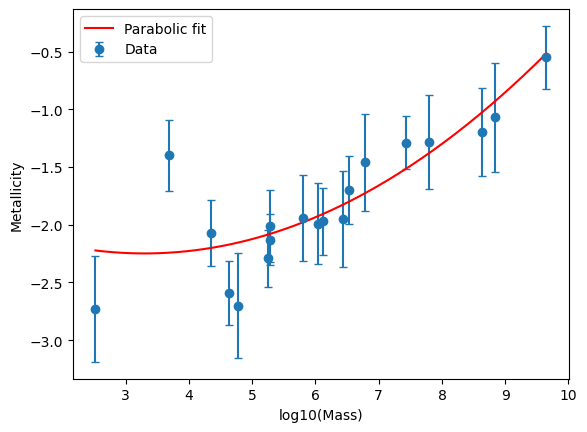

In [64]:
# Define parabola model
def parabola(x, a, b, c):
    return a*x**2 + b*x + c

# Weighted fit using curve_fit
popt, pcov = curve_fit(parabola, x, y, sigma=sy, absolute_sigma=True)
a_par, b_par, c_par = popt
sigma_a_par, sigma_b_par, sigma_c_par = np.sqrt(np.diag(pcov))

# Covariance and correlation matrix
cov_matrix = pcov
r_ab = cov_matrix[0,1] / (sigma_a_par*sigma_b_par)
r_ac = cov_matrix[0,2] / (sigma_a_par*sigma_c_par)
r_bc = cov_matrix[1,2] / (sigma_b_par*sigma_c_par)

# Goodness of fit
y_model = parabola(x, *popt)
chi2 = np.sum(((y - y_model)/sy)**2)
dof = len(x) - 3  # 3 parameters
chi2_red = chi2 / dof

# Print results
print("Parabolic fit results:")
print(f" a = {a_par:.4f} ± {sigma_a_par:.4f}")
print(f" b = {b_par:.4f} ± {sigma_b_par:.4f}")
print(f" c = {c_par:.4f} ± {sigma_c_par:.4f}")
print("\nCorrelations:")
print(f"r_ab = {r_ab:.4f}, r_ac = {r_ac:.4f}, r_bc = {r_bc:.4f}")
print("\nGoodness of fit:")
print(f"chi2 = {chi2:.2f}, chi2_red = {chi2_red:.2f}, dof = {dof}")

# Plot
x_fit = np.linspace(np.min(x), np.max(x), 200)
plt.errorbar(x, y, yerr=sy, fmt='o', capsize=3, label='Data')
plt.plot(x_fit, parabola(x_fit, *popt), '-', color='red', label='Parabolic fit')
plt.xlabel("log10(Mass)")
plt.ylabel("Metallicity")
plt.legend()
plt.show()

$\chi^2$ is closer to one and $r$ i still shows correlation between the uncertainties which means the parabolic fit could be a better model

# Exercise 3 - Preparation to MCMC fitting

**(A)** Read the blog entry "*Bayesian inference problem, MCMC and variational inference*" that you can find at this link: https://towardsdatascience.com/bayesian-inference-problem-mcmc-and-variational-inference-25a8aa9bce29

You can skip the part on Variational Inference, but please read carefully the parts on Bayesian inference and MCMC. After reading this text, write a brief answer (in your words!) to each of the following questions:

* What does each of the terms in Bayes' Theorem represent?
* If you had no knowledge about the probability for some event to occur, what type of distribution would you use for the prior?
* If you had new observations about the probability for some event to occur, how would you incorporate this in a Bayesian framework?
* What does MCMC mean? What is it?
* What is the main purpose of MCMC, and how is it related to Bayesian inference?

**Bayes' Theorem:**

$$
P(\theta \mid x) = \frac{P(x \mid \theta) \, P(\theta)}{P(x)}
$$

- **Prior** $P(\theta)$ : belief about $\theta$ before seeing data  
- **Likelihood** $P(x \mid \theta)$ : probability of observing data ($x$) given $\theta$  
- **Evidence** $P(x)$ : overall probability of the data (normalization)  
- **Posterior** $P(\theta \mid x)$ : updated belief about $\theta$ after seeing data



**Priors:** If I had no knowledge about the initial probability distribution, it would be best to use a flat/uniform distribution for the prior

**Updating with new data:** Incorporate the data into the likelihood $P(x \mid \theta)$ and use the formula above to compute the posterior which is the updated belief about the model

**MCMC:** Markov Chain Monte Carlo. Two separate components:
- Markov Chain: each new event only depends on the previous one
- Monte Carlo method: random sampling to approximate properties

it generates samples from a probability distribution

**Purpose of MCMC:** used to approximate the posterior distribution as the normalization $P(x)$ is often difficult to compute


**(B)** The ```emcee``` package is a python implementation of a MCMC ensemble sampler, and is widely used in astronomy. In this task you will only have to install the packages ```emcee``` and ```corner``` (which is useful for plotting results) on your computer. You should be able to simply use ```pip``` to do that. 

If you need help, you can take a look at the "Installation" section in the webpage containing the documentation of ```emcee```: https://emcee.readthedocs.io/en/stable/. 

When you have installed these packages, run the following cell to make sure that everything went well and that you can indeed import them without errors.

In [65]:
import emcee   #likely need to install with pip first... e.g.,   pip install emcee
import corner  #likely need to install with pip first... e.g.,   pip install corner